# Single-cell analysis: LiFi 1.0 (LED) vs LiFi 2.0 (VCSEL)

This notebook implements a single-cell analysis for the comparative study between LiFi 1.0 and LiFi 2.0. It is divided into two stages because each one answers a different question.

**Phase 1** investigates how the channel models differ when both technologies operate under the same conditions: identical transmit power and an identical receiver. The channel gain is analyzed in two steps: first without the receiver field of view (what each source can cover by itself) and then with the receiver FoV applied.

**Phase 2** investigates how both technologies perform under realistic operating conditions. In this case, each transmitter operates within its own practical constraints, allowing the impact of illumination and eye-safety requirements to be evaluated.

Every paper cited in this notebook is stored in the [`sources/`](sources/) folder.

**Table of contents**  

[1. References](#1.-References)  
[2. Common scenario](#2.-Common-scenario)  
[3. Phase 1 - Ideal single-cell channel comparison](#3.-Phase-1---Ideal-single-cell-channel-comparison)  
&nbsp;&nbsp;&nbsp;&nbsp;[3.1 Channel models and the unified receiver FoV](#3.1-Channel-models-and-the-unified-receiver-FoV)  
&nbsp;&nbsp;&nbsp;&nbsp;[3.2 Source-only channel-gain maps - no receiver FoV](#3.2-Source-only-channel-gain-maps---no-receiver-FoV)  
&nbsp;&nbsp;&nbsp;&nbsp;[3.3 Channel-gain maps with the receiver FoV applied](#3.3-Channel-gain-maps-with-the-receiver-FoV-applied)  
&nbsp;&nbsp;&nbsp;&nbsp;[3.4 Radial profile](#3.4-Radial-profile)  
&nbsp;&nbsp;&nbsp;&nbsp;[3.5 Received power, SNR and achievable rate at the normalization power](#3.5-Received-power,-SNR-and-achievable-rate-at-the-normalization-power)  
&nbsp;&nbsp;&nbsp;&nbsp;[3.6 Coverage vs. SNR threshold](#3.6-Coverage-vs.-SNR-threshold)  
&nbsp;&nbsp;&nbsp;&nbsp;[3.7 Phase 1 discussion](#3.7-Phase-1-discussion)  
[4. Phase 2 - Realistic single-cell analysis](#4.-Phase-2---Realistic-single-cell-analysis)  
&nbsp;&nbsp;&nbsp;&nbsp;[4.1 LiFi 1.0 power - illuminance requirement](#4.1-LiFi-1.0-power---illuminance-requirement)  
&nbsp;&nbsp;&nbsp;&nbsp;[4.2 LiFi 2.0 power - eye safety IEC 60825-1](#4.2-LiFi-2.0-power---eye-safety-IEC-60825-1)  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[4.2.1 Limitation of the eye-safety power estimation](#4.2.1-Limitation-of-the-eye-safety-power-estimation)  
&nbsp;&nbsp;&nbsp;&nbsp;[4.3 Coverage under realistic power](#4.3-Coverage-under-realistic-power)  
&nbsp;&nbsp;&nbsp;&nbsp;[4.4 Summary table and energy efficiency](#4.4-Summary-table-and-energy-efficiency)  
&nbsp;&nbsp;&nbsp;&nbsp;[4.5 Spectral consideration - wavelength-dependent responsivity](#4.5-Spectral-consideration---wavelength-dependent-responsivity)  
[5. Interpretation](#5.-Interpretation)  
&nbsp;&nbsp;&nbsp;&nbsp;[5.1 From a single VCSEL to an array](#5.1-From-a-single-VCSEL-to-an-array)  
&nbsp;&nbsp;&nbsp;&nbsp;[5.2 Scaling analysis - equivalent optical power from multiple VCSELs](#5.2-Scaling-analysis---equivalent-optical-power-from-multiple-VCSELs)  
[6. Transition to the multi-cell analysis](#6.-Transition-to-the-multi-cell-analysis)

## 1. References

| Key | Paper | Used for |
|---|---|---|
| `[RIS-VLC]` | [Resource Allocation Exploiting Reflective Surfaces to Minimize the Outage Probability in VLC](<sources/Resource_Allocation_Exploiting_Reflective_Surfaces_to_Minimize_the_Outage_Probability_in_VLC%20(1).pdf>) | LiFi 1.0 Lambertian LOS channel — eq. (1); optical power → illuminance — eq. (25); SNR — eq. (12); FoV coverage radius — eq. (11); parameters ($K_{e/v}$, FoV, $B$, $N_0$) — Table III |
| `[VCSEL-Precoding]` | Safi et al., [Energy-Efficient Precoding for Dense VCSEL-Based OWC Systems Under a Cooperative Broadcast Model](<sources/Energy-Efficient_Precoding_for_Dense_VCSEL-Based_OWC_Systems_Und.pdf>) | LiFi 2.0 single-VCSEL Gaussian-beam channel — eqs. (2)–(8); non-imaging concentrator gain (Kahn–Barry model), applied here to the receiver of *both* technologies — eq. (8); parameters ($w_0$, $\lambda$, $n$, $A_{PD}$, $\rho$, $B$) — Table I |
| `[Capacity-Bound]` | Wang et al., [Tight Bounds on Channel Capacity for Dimmable Visible Light Communications](<sources/TightBoundsonChannelCapacityforDimmableVisibleLightCommunications.pdf>) | Achievable-rate lower bound for both technologies — eq. (37) (cited as [39] in `[RIS-VLC]` and [31] in `[VCSEL-Precoding]`) |
| `[Eye-Safety]` | Soltani et al., [Safety Analysis for Laser-Based Optical Wireless Communications: A Tutorial](<sources/Safety_Analysis_for_Laser-Based_Optical_Wireless_Communications_A_Tutorial.pdf>) | Max eye-safe CW power of a single-mode VCSEL — Algorithm 1, eq. (36), divergence eq. (8); IEC 60825-1:2014 near-IR MPE — Table 4 |
| `[VCSEL-70Gbps]` | Kazemi et al. 2025, [Achieving 70 Gb/s Over a VCSEL-Based Optical Wireless Link Using a Multi-Mode Fiber-Coupled Receiver](<sources/achieving_70gbs_vcsel_wirelesslink_multimodefiber.pdf>) | Experimental single-VCSEL operating power (~5 mW, 940 nm) as an eye-safety cross-check — Table I / abstract |


----

## 2. Common scenario

Everything here stays the same across both phases and both technologies: the room, the ceiling/desk height, the transmitter position, the photodetector, and the receiver grid. The only parameters that change later on are the ones related to channel model (Phase 1) and the transmit power (Phase 2).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# room and tx/rx geometry, shared by every cell in the code below 

ROOM_X, ROOM_Y = 5.0, 5.0 # room floor size [m] (typical attocell footprint)
TX_HEIGHT = 3.0 # tx height, mounted on the ceiling [m]
RX_HEIGHT = 1.0 # rx height, desk level [m]
TX_POS = np.array([ROOM_X / 2, ROOM_Y / 2, TX_HEIGHT]) # tx at the center of the ceiling
dz = TX_HEIGHT - RX_HEIGHT # vertical tx-rx separation [m], used everywhere below

APD = 1e-4 # photodetector active area A_PD [m^2] = 1 cm^2 ([RIS-VLC] Table III / [VCSEL-Precoding] Table I)
RHO = 1.0 # photodetector responsivity rho [A/W], same in both papers (see Section 4.5)

# receiver grid: N x N points covering the whole floor
N = 300
xs = np.linspace(0, ROOM_X, N)
ys = np.linspace(0, ROOM_Y, N)
X, Y = np.meshgrid(xs, ys)

r0 = np.sqrt((X - TX_POS[0])**2 + (Y - TX_POS[1])**2) # horizontal distance from tx to each rx point [m]
d3d = np.sqrt(r0**2 + dz**2) # straight-line tx-rx distance [m]
theta = np.arctan2(r0, dz) # irradiance/incidence angle seen from tx [rad]

print(f"Room {ROOM_X:.0f}x{ROOM_Y:.0f}x{TX_HEIGHT:.0f} m")
print(f"Tx-Rx vertical separation = {dz:.1f} m")

Room 5x5x3 m
Tx-Rx vertical separation = 2.0 m


## 3. Phase 1 - Single-cell channel comparison

In this phase, everything is kept constant except the channel model: same room, same Tx/Rx geometry, same $A_{PD}$ and $\rho$, same treatment of the receiver FoV, and both transmitters send the same normalization power, $P_{tx} = 1\,\text{W}$

The 1 W value is set just so both technologies are compared under the exact same conditions. The goal of this first analysis is only to see how the Lambertian and the Gaussian-beam models differ, without power getting in the way.

### 3.1 Channel models and receiver FoV

The field of view (FoV) is a property of the receiver (photodiode and optics), not the transmitter. Therefore, the FoV must be identical for both technologies if we want to have a fair comparison:

- The reference papers use different semiangles (40° in `[RIS-VLC]` and 60° in `[VCSEL-Precoding]`) simply because they assume different receiver designs, not because LiFi 1.0 and LiFi 2.0 inherently require them. However, keeping different values would mean comparing two different receivers rather than the transmitters.

- We use a single receiver model for both cases: a photodiode with an area of $A_{PD} = 1\,\text{cm}^2$ and an optical concentrator (refractive index $n = 1.5$ and acceptance semiangle $\Psi_c = 40°$, taken from `[RIS-VLC]`). It follows the standard Kahn–Barry model: gain $G = n^2/\sin^2\Psi_c$ for incidence angles within the FoV, and zero otherwise.

- Applying this gain $G$ to the Lambertian channel is our only change to the original `[RIS-VLC]` equation (which originally lacked a concentrator). We do this to ensure the receiver is exactly the same in both branches.

- We assume the receiver is pointing straight up. Since tilting the device would shift the coverage area, we split the analysis: Section 3.2 shows the channel gain without the FoV restriction (the raw coverage capability of each source), and Section 3.3 applies the receiver FoV restriction.

In [ ]:
# LiFi 1.0: LED, Lambertian, LOS only

# Channel model [RIS-VLC] eq. (1):  H_LoS = (m+1)*A_PD/(2*pi*d^2) * cos^m(phi) * cos(psi),  0 <= psi <= Psi
# Lambertian order  [RIS-VLC] eq. (1):  m = -1 / log2(cos(phi_1/2))

PHI_HALF_DEG = 80.0  # LED half-power semiangle [deg], [RIS-VLC] Table III
m_led = -1.0 / np.log2(np.cos(np.deg2rad(PHI_HALF_DEG)))  # Lambertian order

# emitter points down and rx points up => irradiance angle phi = incidence angle psi = theta
H_led_src = (m_led + 1) * APD / (2 * np.pi * d3d**2) * np.cos(theta)**m_led * np.cos(theta)

m_led = 0.396
Unified receiver: Psi_c = 40 deg -> G_conc = 5.446
Receiver FoV footprint radius on the desk plane: 1.68 m (same for both technologies)
VCSEL beam radius on the desk plane: w(dz) = 1.34 m


In [ ]:
# LiFi 2.0: single VCSEL, Gaussian beam ([VCSEL-Precoding], Safi et al., eqs. (2)-(8))
W0 = 0.45e-6    # beam waist w0 at the VCSEL aperture [m], [VCSEL-Precoding] Table I
LAMBDA = 950e-9 # VCSEL wavelength lambda [m], [VCSEL-Precoding] Table I

zR = np.pi * W0**2 / LAMBDA  # Rayleigh range of the beam [m], [VCSEL-Precoding] eq. (2)
wz = W0 * np.sqrt(1 + (d3d / zR)**2) # beam radius at distance d3d [m], [VCSEL-Precoding] eq. (6)
Z_irr = 2 / (np.pi * wz**2) * np.exp(-2 * r0**2 / wz**2) # Gaussian irradiance profile, [VCSEL-Precoding] eq. (7)
H_vcsel_src = Z_irr * APD # source-only VCSEL gain (PD, no concentrator)

In [ ]:
# Receiver side: unified PD + concentrator, identical for both 

PSI_C_DEG = 40.0  # receiver FoV semiangle Psi_c [deg], same for both technologies ([RIS-VLC] Table III lists 30/40/50)
N_LENS = 1.5  # concentrator refractive index n, [VCSEL-Precoding] eq. (8)

PSI_C = np.deg2rad(PSI_C_DEG)
G_CONC = N_LENS**2 / np.sin(PSI_C)**2  # non-imaging concentrator gain G, [VCSEL-Precoding] eq. (8) (Kahn-Barry)
in_fov = theta <= PSI_C # unified receiver FoV mask (receiver pointing straight up)
r_fov = dz * np.tan(PSI_C) # FoV footprint radius on the desk plane [m], [RIS-VLC] eq. (11)

# full channel gain = source shape x concentrator gain, zero outside the receiver FoV
H_led = np.where(in_fov, H_led_src * G_CONC, 0.0)
H_vcsel = np.where(in_fov, H_vcsel_src * G_CONC, 0.0)

print(f"m_led = {m_led:.3f}")
print(f"Unified receiver: Psi_c = {PSI_C_DEG:.0f} deg -> G_conc = {G_CONC:.3f}")
print(f"Receiver FoV footprint radius on the desk plane: {r_fov:.2f} m (same for both technologies)")
print(f"VCSEL beam radius on the desk plane: w(dz) = {W0*np.sqrt(1+(dz/zR)**2):.2f} m")

### 3.2 Source-only channel gain (without receiver FoV)

Before applying any receiver constraints, these maps show the gain each source delivers to the desk plane. This represents what a simple, upward-facing photodiode would receive without a concentrator or angular cut-off, showing the true coverage capability of each source independently of the user's receiver setup.

**Notes from the maps**
* **No cut-offs:** The LED illuminates the entire room with a smooth Lambertian decay, and the Gaussian beam stays positive everywhere. Without receiver FoV limits, both sources reach the whole floor—just with very different intensity distributions.

* **The LED is highly uniform:** The gain varies by only about 10 dB from the center of the room to the corners, meaning the Lambertian pattern spreads the power almost evenly.

* **The VCSEL concentrates the power:** It delivers a higher peak gain directly under the transmitter but drops off much faster with distance. It loses about 20 dB toward the corners, even though this specific beam profile is already quite wide (see Section 4.2.1).

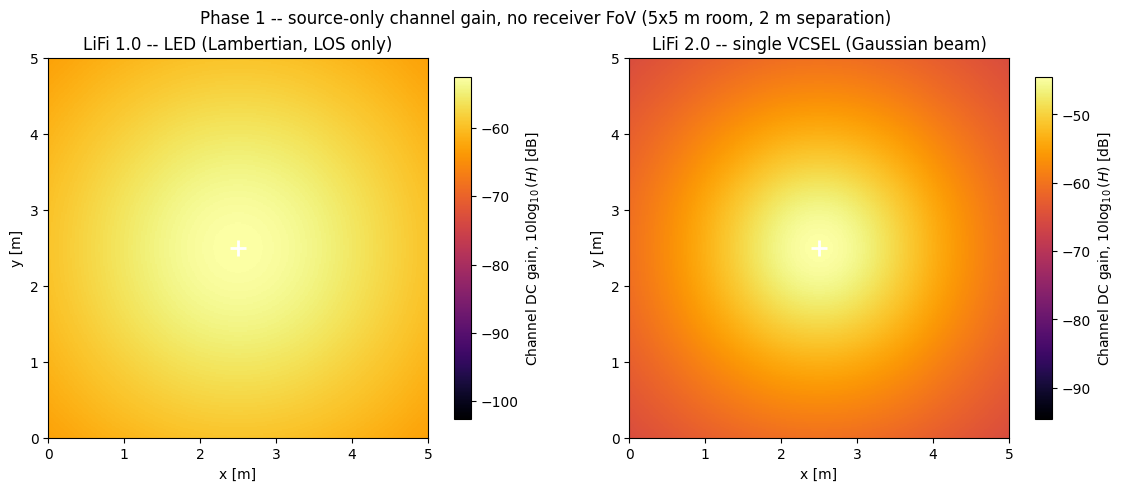

LED source-only gain: center = -52.6 dB, corner = -63.0 dB (drop = 10.4 dB)
VCSEL source-only gain: center = -44.5 dB, corner = -65.3 dB (drop = 20.7 dB)


In [ ]:
H_led_src_dB = 10 * np.log10(H_led_src)      # source-only gains are strictly positive, so no masking needed
H_vcsel_src_dB = 10 * np.log10(H_vcsel_src)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), constrained_layout=True)
maps_src = [(H_led_src_dB,   "LiFi 1.0 -- LED (Lambertian, LOS only)"),
            (H_vcsel_src_dB, "LiFi 2.0 -- single VCSEL (Gaussian beam)")]

for ax, (H_dB, title) in zip(axes, maps_src):
    vmax = np.nanmax(H_dB)
    im = ax.pcolormesh(X, Y, H_dB, shading="auto", cmap="inferno", vmin=vmax - 50, vmax=vmax)
    ax.plot(*TX_POS[:2], "w+", markersize=12, mew=2)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(0, ROOM_X)
    ax.set_ylim(0, ROOM_Y)
    fig.colorbar(im, ax=ax, label=r"Channel DC gain, $10\log_{10}(H)$ [dB]", shrink=0.9)
fig.suptitle("Phase 1 -- source-only channel gain, no receiver FoV "
             f"({ROOM_X:.0f}x{ROOM_Y:.0f} m room, {dz:.0f} m separation)")
plt.show()

print(f"LED source-only gain: center = {H_led_src_dB.max():.1f} dB, "
      f"corner = {H_led_src_dB.min():.1f} dB (drop = {H_led_src_dB.max()-H_led_src_dB.min():.1f} dB)")
print(f"VCSEL source-only gain: center = {H_vcsel_src_dB.max():.1f} dB, "
      f"corner = {H_vcsel_src_dB.min():.1f} dB (drop = {H_vcsel_src_dB.max()-H_vcsel_src_dB.min():.1f} dB)")

### 3.3 Channel-gain maps with the receiver FoV applied

Same channel shape as above, but now seen by the actual receiver: concentrator gain $G$ inside the FoV, zero outside.

- A receiver only "sees" the transmitter while the incidence angle stays within its field-of-view semiangle $\Psi_c$. With the receiver pointing straight up, on the desk plane this maps to a coverage *disk* of radius

$$r_\text{FoV} = \Delta z\,\tan(\Psi_c),$$

which with $\Psi_c = 40°$ and $\Delta z = 2$ m gives $r_\text{FoV} = 1.68$ m for both technologies. Outside this disk the non-imaging concentrator gain is zero, so $H=0$ and $10\log_{10}H\to-\infty$ (rendered in black).

**Notes from the maps**
- The difference with respect to the maps in Section 3.2 is entirely caused by the receiver: everything outside the FoV disk is cut to exactly zero, regardless of how much light the source delivers there.
- The FoV disk covers only ~35% of this 5x5 m room, so the receiver FoV, not the source, is what bounds the maximum coverage area in the rest of Phase 1 (both technologies share the same geometric ceiling now that the receiver is unified).
- Inside the disk, the relative shapes are the ones already seen in 3.2: nearly flat for the LED, strongly peaked around the axis for the VCSEL.

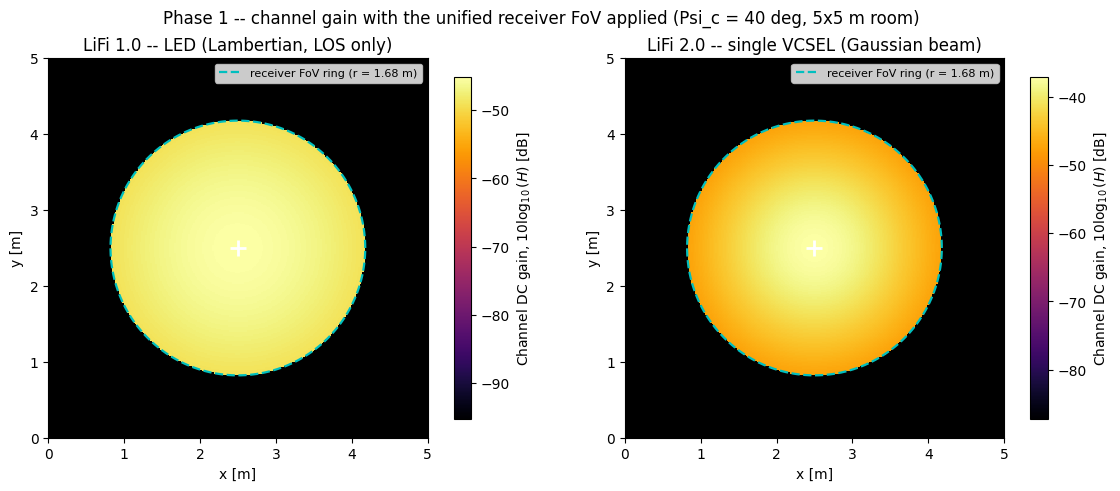

In [ ]:
def to_dB(H):
    # channel gain in dB
    with np.errstate(divide="ignore"):
        return np.where(H > 0, 10 * np.log10(H), np.nan)

H_led_dB = to_dB(H_led)
H_vcsel_dB = to_dB(H_vcsel)

cmap = plt.cm.inferno.copy()
cmap.set_bad("black")  # NaN (outside the receiver FoV) rendered as true black

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), constrained_layout=True)
maps = [(H_led_dB,   "LiFi 1.0 - LED (Lambertian, LOS only)"),
        (H_vcsel_dB, "LiFi 2.0 - single VCSEL (Gaussian beam)")]
th = np.linspace(0, 2 * np.pi, 200)
for ax, (H_dB, title) in zip(axes, maps):
    vmax = np.nanmax(H_dB)
    im = ax.pcolormesh(X, Y, H_dB, shading="auto", cmap=cmap, vmin=vmax - 50, vmax=vmax)
    ax.plot(TX_POS[0] + r_fov * np.cos(th), TX_POS[1] + r_fov * np.sin(th),
            "c--", lw=1.6, label=f"receiver FoV ring (r = {r_fov:.2f} m)")
    ax.plot(*TX_POS[:2], "w+", markersize=12, mew=2)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(0, ROOM_X)
    ax.set_ylim(0, ROOM_Y)
    ax.legend(loc="upper right", fontsize=8)
    fig.colorbar(im, ax=ax, label=r"Channel DC gain, $10\log_{10}(H)$ [dB]", shrink=0.9)
fig.suptitle("Phase 1: channel gain with the unified receiver FoV applied "
             f"(Psi_c = {PSI_C_DEG:.0f} deg, {ROOM_X:.0f}x{ROOM_Y:.0f} m room)")
plt.show()

### 3.4 Radial profile

This plot shows the exact same channel gain, but sliced along a straight line moving outward from directly under the transmitter, making it much easier to compare the LED and VCSEL shapes. 

* **Thin, faded lines:** Show the raw, source-only gain (from Section 3.2).
* **Solid lines:** Include the full receiver model, adding both the concentrator gain and the FoV cut-off (from Section 3.3).

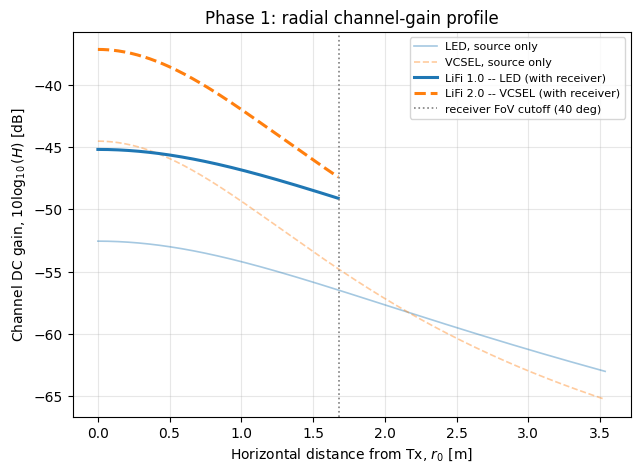

In [ ]:
r0_line = np.linspace(1e-3, np.hypot(ROOM_X, ROOM_Y) / 2, 400)  # horizontal distance samples [m]
d_line = np.sqrt(r0_line**2 + dz**2)  # straight-line tx-rx distance along that line [m]
th_line = np.arctan2(r0_line, dz) # incidence angle along that line [rad]

# source-only gains along the line (same formulas as Section 3.2)
Hl_src_line = (m_led + 1) * APD / (2 * np.pi * d_line**2) * np.cos(th_line)**m_led * np.cos(th_line)
wz_line = W0 * np.sqrt(1 + (d_line / zR)**2)  # VCSEL beam radius along the line [m]
Hv_src_line = 2 / (np.pi * wz_line**2) * np.exp(-2 * r0_line**2 / wz_line**2) * APD

# receiver applied: concentrator gain inside the FoV, NaN outside so it just doesn't plot
Hl_line = np.where(th_line <= PSI_C, Hl_src_line * G_CONC, np.nan)
Hv_line = np.where(th_line <= PSI_C, Hv_src_line * G_CONC, np.nan)

fig, ax = plt.subplots(figsize=(7.2, 5))
ax.plot(r0_line, 10 * np.log10(Hl_src_line), color="tab:blue", lw=1.2, alpha=0.4, label="LED, source only")
ax.plot(r0_line, 10 * np.log10(Hv_src_line), color="tab:orange", lw=1.2, alpha=0.4, ls="--", label="VCSEL, source only")
ax.plot(r0_line, 10 * np.log10(Hl_line), color="tab:blue", lw=2.2, label="LiFi 1.0 -- LED (with receiver)")
ax.plot(r0_line, 10 * np.log10(Hv_line), color="tab:orange", lw=2.2, ls="--", label="LiFi 2.0 -- VCSEL (with receiver)")
ax.axvline(r_fov, color="gray", ls=":", lw=1.2, label=f"receiver FoV cutoff ({PSI_C_DEG:.0f} deg)")
ax.set_xlabel(r"Horizontal distance from Tx, $r_0$ [m]")
ax.set_ylabel(r"Channel DC gain, $10\log_{10}(H)$ [dB]")
ax.set_title("Phase 1: radial channel-gain profile")
ax.legend(fontsize=8)
ax.grid(alpha=.3)
plt.show()

### 3.5 Received power, SNR and achievable rate at the normalization power

The achievable rate is computed using

$$
R=\frac{B}{2}\log_2\left(1+\frac{e}{2\pi}\mathrm{SNR}\right),
$$

which is the lower bound commonly adopted for IM/DD systems, from `[Capacity-Bound]`. Both `[RIS-VLC]` and `[VCSEL-Precoding]` use this expression instead of the classical Shannon capacity because optical wireless communication uses intensity modulation with non-negative signals, making the standard Shannon expression less appropriate.

For the noise, we assume the same PSD $N_0$ for both technologies. The `[RIS-VLC]` paper gives a value for $N_0$, `[VCSEL-Precoding]` doesn't, so I reuse the same one for the VCSEL under the assumption that the receiver itself doesn't change. This way any difference in the results comes from the transmitter and the channel, not from an arbitrary noise choice. Even with the same $N_0$, the total noise power still differs between the two because the bandwidth is different (20 MHz for LiFi 1.0, 2 GHz for LiFi 2.0).

This is a simplification since a GHz-class receiver wouldn't really share the exact same noise characteristics as one built for a few tens of MHz; but keeping $N_0$ fixed allows to isolate the effect of the propagation model, which is the actual point of this first part.


In [6]:
N0 = 2.5e-20   # noise PSD N0 [W/Hz], [RIS-VLC] (reused for LiFi 2.0)
B1 = 20e6      # LiFi 1.0 bandwidth [Hz], [RIS-VLC] Table III
B2 = 2e9       # LiFi 2.0 bandwidth [Hz], [VCSEL-Precoding] Table I
K_BOUND = np.e / (2 * np.pi)  # constant e/(2*pi) in the rate bound, [Capacity-Bound] eq. (37)

def snr_rate(Ptx_led, Ptx_vcsel):
    Pr_led = Ptx_led * H_led # received optical power, LED [W]
    Pr_vcsel = Ptx_vcsel * H_vcsel # received optical power, VCSEL [W]
    SNR_led = (RHO * Pr_led)**2 / (N0 * B1)   
    SNR_vcsel = (RHO * Pr_vcsel)**2 / (N0 * B2)
    # achievable-rate lower bound R = (B/2)*log2(1 + (e/2pi)*SNR), [Capacity-Bound] eq. (37)
    R_led = 0.5 * B1 * np.log2(1 + K_BOUND * SNR_led)   # [bit/s]
    R_vcsel = 0.5 * B2 * np.log2(1 + K_BOUND * SNR_vcsel) # [bit/s]
    return Pr_led, Pr_vcsel, SNR_led, SNR_vcsel, R_led, R_vcsel

PTX_NORM = 1.0  # normalization power for Phase 1 [W], same for both transmitters
Pr_led1, Pr_vcsel1, SNR_led1, SNR_vcsel1, R_led1, R_vcsel1 = snr_rate(PTX_NORM, PTX_NORM)

print(f"Phase 1 @ Ptx = {PTX_NORM:.0f} W (both):")
print(f"  LiFi 1.0: peak Pr={np.nanmax(Pr_led1)*1e3:.3f} mW, peak SNR={10*np.log10(np.nanmax(SNR_led1)):.1f} dB "
      f", peak rate={np.nanmax(R_led1)/1e6:.1f} Mbit/s")
print(f"  LiFi 2.0: peak Pr={np.nanmax(Pr_vcsel1)*1e3:.3f} mW, peak SNR={10*np.log10(np.nanmax(SNR_vcsel1)):.1f} dB "
      f", peak rate={np.nanmax(R_vcsel1)/1e6:.1f} Mbit/s")


Phase 1 @ Ptx = 1 W (both):
  LiFi 1.0: peak Pr=0.030 mW, peak SNR=32.6 dB , peak rate=96.3 Mbit/s
  LiFi 2.0: peak Pr=0.192 mW, peak SNR=28.7 dB , peak rate=8320.2 Mbit/s


### 3.6 Coverage vs. SNR threshold

Instead of picking one SNR threshold and reporting a single coverage number, I sweep the threshold and plot the whole curve to show a lot more about how the two channels behave 


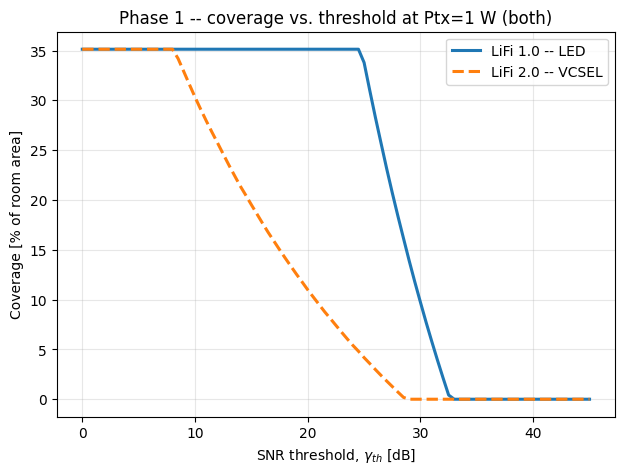

In [7]:
th_range_dB = np.linspace(0, 45, 91)  # SNR thresholds to sweep [dB]
cov_led_curve, cov_vcsel_curve = [], []
for th_dB in th_range_dB:
    g = 10**(th_dB / 10)  # threshold converted to linear scale
    cov_led_curve.append(100 * np.mean(SNR_led1 >= g))      # % of room area above threshold, LED
    cov_vcsel_curve.append(100 * np.mean(SNR_vcsel1 >= g))  # % of room area above threshold, VCSEL

fig, ax = plt.subplots(figsize=(7.2, 5))
ax.plot(th_range_dB, cov_led_curve, lw=2.2, label="LiFi 1.0 -- LED")
ax.plot(th_range_dB, cov_vcsel_curve, lw=2.2, ls="--", label="LiFi 2.0 -- VCSEL")
ax.set_xlabel(r"SNR threshold, $\gamma_{th}$ [dB]")
ax.set_ylabel("Coverage [% of room area]")
ax.set_title(f"Phase 1 -- coverage vs. threshold at Ptx={PTX_NORM:.0f} W (both)")
ax.legend()
ax.grid(alpha=.3)
plt.show()


In [ ]:


diff = np.array(cov_vcsel_curve) - np.array(cov_led_curve)
sign_changes = np.where(np.diff(np.sign(diff)) != 0)[0]

print("Crossing point(s) between the LED and VCSEL coverage-vs-threshold curves:")
for idx in sign_changes:
    if max(cov_led_curve[idx + 1], cov_vcsel_curve[idx + 1]) < 0.1:
        continue  # not a real crossing, both curves are already at zero coverage
    th1, th2 = th_range_dB[idx], th_range_dB[idx + 1]
    d1, d2 = diff[idx], diff[idx + 1]
    th_cross = th1 - d1 * (th2 - th1) / (d2 - d1)
    print(f"  ~{th_cross:4.1f} dB  (LED~{cov_led_curve[idx]:.1f}%, VCSEL~{cov_vcsel_curve[idx]:.1f}%)")

fov_disk_pct = 100 * np.pi * r_fov**2 / (ROOM_X * ROOM_Y)
print(f"\nShared FoV-disk geometric max coverage: {fov_disk_pct:5.1f}% of the room "
      "(both curves saturate at this value at low thresholds)")

# SNR at the FoV-disk edge @1W: 
d_edge = np.hypot(r_fov, dz)
Hl_edge = (m_led + 1) * APD / (2 * np.pi * d_edge**2) * np.cos(PSI_C)**m_led * np.cos(PSI_C) * G_CONC
wz_edge = W0 * np.sqrt(1 + (d_edge / zR)**2)
Hv_edge = 2 / (np.pi * wz_edge**2) * np.exp(-2 * r_fov**2 / wz_edge**2) * APD * G_CONC
print(f"SNR at the FoV-disk edge @ 1 W: LED = {10*np.log10((RHO*Hl_edge)**2/(N0*B1)):.1f} dB, "
      f"VCSEL = {10*np.log10((RHO*Hv_edge)**2/(N0*B2)):.1f} dB")

Crossing point(s) between the LED and VCSEL coverage-vs-threshold curves:
  ~ 8.0 dB  (LED~35.1%, VCSEL~35.1%)

Shared FoV-disk geometric max coverage:  35.4% of the room (both curves saturate at this value at low thresholds)
SNR at the FoV-disk edge @ 1 W: LED = 24.8 dB, VCSEL = 8.1 dB


### 3.7 Phase 1 discussion

* **Both curves start at the same maximum coverage level (~35% of the room):** Because we use the same receiver, both technologies share the exact same FoV disk, making their maximum coverage identical. At low SNR thresholds, 1 W is enough for both to cover this entire area. Lowering the threshold further doesn't increase coverage because the limit is the receiver's FoV, not the transmitters.

* **The VCSEL drops from this maximum coverage much earlier (~8 dB) than the LED (~25 dB):** This shows the SNR at the edge of the FoV disk. The Gaussian beam concentrates its power in the center (its beam radius is ~1.34 m, while the FoV radius is 1.68 m), meaning the edge of the disk falls on the tail of the beam and loses coverage quickly as the threshold rises. The LED's Lambertian pattern stays uniform across the disk, keeping it fully covered up to much higher thresholds.

* **The LED reaches a higher peak SNR (~33 dB vs ~29 dB), despite the VCSEL having ~8 dB more channel gain at the center:** This is due to bandwidth. At the same noise level ($N_0$), the VCSEL's 100x larger bandwidth (2 GHz vs. 20 MHz) adds 20 dB of noise power, wiping out its channel-gain advantage. However, the VCSEL trades this SNR for speed: its peak rate is ~8.3 Gbit/s compared to the LED's ~96 Mbit/s.

**Phase 1 conclusion** With equal power and the same receiver, the LED gives equal or better coverage at every SNR threshold because it spreads power uniformly. The VCSEL provides a massive peak rate near the center thanks to its bandwidth. This isolates the impact of the channel models (Lambertian vs. Gaussian) and bandwidth, setting up Phase 2 to look at real-world practices.

---

## 4. Phase 2 - Realistic single-cell analysis

Here the question changes. Phase 1 asked "how do the channels compare", Phase 2 asks "what actually happens once each technology is limited by its own real constraints." So instead of the arbitrary 1 W for both, each transmitter now gets the power it would realistically use.


### 4.1 LiFi 1.0 power - illuminance requirement

The LED power is obtained from an illuminance target: 500 lux, the standard EN 12464-1 value for office/reading tasks, and also the target used in the `[RIS-VLC]` reference paper (Sec. V). The same Lambertian model from Phase 1 is used, but now written in terms of illuminance instead of gain.

The $A_{PD}$ term cancels out because illuminance describes the light field itself, not any particular detector:

$$E_v(0) = K_{e/v}\cdot P_{tx}\cdot\frac{m+1}{2\pi d_z^2}\quad\Rightarrow\quad
P_{tx}=\frac{E_{target}}{E_v(0)/P_{tx}}$$

The `[RIS-VLC]` paper's own optimized benchmark (Fig. 15) uses 4 LEDs together reaching 500 lux average in a 4x4x3 m room, with about 82-90 W total (roughly 20-22 W per LED). The isolated LED used in this analysis needs somewhat more than that per-LED figure, which makes sense as in their case four LEDs share the work of lighting the room, so one LED on its own has to work harder.

> Here the power is set so the illuminance directly below the Tx (the peak) equals 500 lux. EN 12464-1 and `[RIS-VLC]` define 500 lux as an average over the task area, so this is a simplification: the room-average illuminance of this single LED is below 500 lux --> $P_{tx}$ here is a lower bound

In [9]:
KE_V = 280.0          # luminous efficacy K_e/v [lm/W], [RIS-VLC] Table III
E_TARGET_LUX = 500.0  # illuminance target [lux], EN 12464-1 office value ([RIS-VLC] Sec. V)

# Illuminance from optical power, [RIS-VLC] eq. (25):  E_v = (K_e/v / A_PD) * P * H_LoS

# directly below tx: H_LoS(0) = (m+1)*A_PD/(2*pi*dz^2), so A_PD cancels:
E_per_watt_boresight = KE_V * (m_led + 1) / (2 * np.pi * dz**2)  # lux produced per watt, directly below the tx
PTX_LED_REALISTIC = E_TARGET_LUX / E_per_watt_boresight          # LED power needed to hit the target [W]
print(f"LiFi 1.0 realistic power (single LED, {E_TARGET_LUX:.0f} lux target): {PTX_LED_REALISTIC:.1f} W")


LiFi 1.0 realistic power (single LED, 500 lux target): 32.2 W


### 4.2 LiFi 2.0 power - eye safety IEC 60825-1

For the VCSEL, the transmit power is limited by eye-safety requirements.

Unlike LEDs, VCSELs are laser sources, meaning that the maximum optical power of a single emitter is constrained by the IEC 60825-1 laser safety standard. Consequently, a single VCSEL cannot operate at the same optical power as a LED.

To obtain a realistic value, the maximum eye-safe power is estimated following the methodology presented in `[Eye-Safety]` (Soltani et al.). This value is also compared with experimentally reported operating powers found in the literature (`[VCSEL-70Gbps]`), confirming that practical single-mode VCSELs typically operate in the milliwatt range.



#### 4.2.1 Limitation of the eye-safety power estimation

The eye-safety limit depends strongly on the assumed beam waist $w_0 = 0.45\ \mu m$ (`[VCSEL-Precoding]` Table I), which is smaller than the VCSEL's wavelength $\lambda = 950\ nm$. The Gaussian-beam model requires $w_0 \gg \lambda$, so this value isn't fully valid here.

Such a small $w_0$ gives an unrealistically large divergence, $\theta \approx \lambda/(\pi w_0) \approx 38º$ half-angle, wider than a real VCSEL beam. This makes the model beam spread and lose intensity faster than a real device would, so less power is assumed to reach the eye, which pushes the estimated safe power up: $P_{tx,max} = 224.9\ mW$, about 45x above the $5\ mW$ experimentally reported in `[VCSEL-70Gbps]`. 
>A more realistic waist (e.g. $w_0 \approx 5\ \mu m$) would bring the estimate down toward that range.

This doesn't change the conclusion: a single VCSEL is still strongly power-limited compared with an LED, but 224.9 mW should be read as an optimistic ceiling, not a practical limit. 

The rest of the analysis uses the more conservative experimental value from the paper, 5 mW.

In [10]:
def mpe_point_long_exposure(lam_nm):
    # IEC 60825-1 point-source MPE, near-IR, long exposure (t_ex > 10 s)
    # [Eye-Safety] Table 4:  MPE = 10 * C4 * C7 [W/m^2];  C4 = 10^(0.002(lam-700));  C7 = 1 for lam < 1150 nm
    C4 = 10**(0.002 * (lam_nm - 700))
    C7 = 1.0 if lam_nm < 1150 else 10**(0.018 * (lam_nm - 1150))
    return 10 * C4 * C7  # MPE [W/m^2]

assert abs(mpe_point_long_exposure(850) - 19.95) < 0.1  # [Eye-Safety]: ~20 W/m^2 at 850 nm (matches the tutorial)
MPE_950 = mpe_point_long_exposure(950)

def eye_safe_ptx(w0, lam, rp=3.5e-3):
    # max eye-safe CW power for a single-mode Gaussian VCSEL beam, [Eye-Safety] Algorithm 1 + eq. (36)
    # w0: beam waist [m], lam: wavelength [m], rp: worst-case dilated pupil radius [m]
    # rp = 3.5 mm -> 7 mm limiting aperture ([Eye-Safety] Sec. II-D)

    zR_ = np.pi * w0**2 / lam       # Rayleigh range, [VCSEL-Precoding] eq. (2) / [Eye-Safety] eq. (5)
    theta_div = lam / (np.pi * w0)  # beam divergence half-angle, [Eye-Safety] eq. (8)
    d86 = (np.pi * w0 / lam) * np.sqrt(-2 * rp**2 / np.log(1 - 0.86))  # distance where the pupil catches 86% of the beam power [m]
    # [Eye-Safety] Algorithm 1, step 1
    if 2 * theta_div > 0.092 and d86 < 0.1:
        zhaz = 0.1  # hazard distance capped at 10 cm for wide-divergence beams ([Eye-Safety] Alg. 1)
    else:
        alpha = 2 * np.arctan(w0 / d86)
        zhaz = w0 / 0.0021 if alpha < 1.5e-3 else 9.2 * np.pi * w0 / (2 * lam)  # [Eye-Safety] Alg. 1
    Wzhaz = w0 * np.sqrt(1 + (zhaz / zR_)**2)  # beam radius at the hazard distance, [Eye-Safety] eq. (4a)
    eta = 1 - np.exp(-2 * rp**2 / Wzhaz**2)    # fraction of beam power entering the pupil
    return (1 / eta) * mpe_point_long_exposure(lam * 1e9) * np.pi * rp**2, zhaz, eta  # Pt,max, [Eye-Safety] eq. (36)

PTX_VCSEL_EYESAFE, zhaz, eta = eye_safe_ptx(W0, LAMBDA)
PTX_VCSEL_EXPERIMENTAL = 5e-3  # [VCSEL-70Gbps] Table I (Pt = 4.26 / 4.95 mW) / abstract ("below 5 mW"), 940 nm

print(f"MPE(950nm, point source, long exposure) = {MPE_950:.1f} W/m^2")
print(f"Theoretical eye-safe ceiling (single bare VCSEL, w0={W0*1e6:.2f} um): {PTX_VCSEL_EYESAFE*1e3:.1f} mW")
print(f"Real experimental operating power ([VCSEL-70Gbps], Kazemi et al. 2025): {PTX_VCSEL_EXPERIMENTAL*1e3:.1f} mW")
print(f"\nRatio LED/VCSEL realistic power: {PTX_LED_REALISTIC/PTX_VCSEL_EYESAFE:.0f}x (vs. eye-safety ceiling) "
      f"/ {PTX_LED_REALISTIC/PTX_VCSEL_EXPERIMENTAL:.0f}x (vs. experimental value)")


MPE(950nm, point source, long exposure) = 31.6 W/m^2
Theoretical eye-safe ceiling (single bare VCSEL, w0=0.45 um): 224.9 mW
Real experimental operating power ([VCSEL-70Gbps], Kazemi et al. 2025): 5.0 mW

Ratio LED/VCSEL realistic power: 143x (vs. eye-safety ceiling) / 6430x (vs. experimental value)


### 4.3 Coverage under realistic power

Same SNR-threshold coverage as before, but now with each technology's own realistic power 


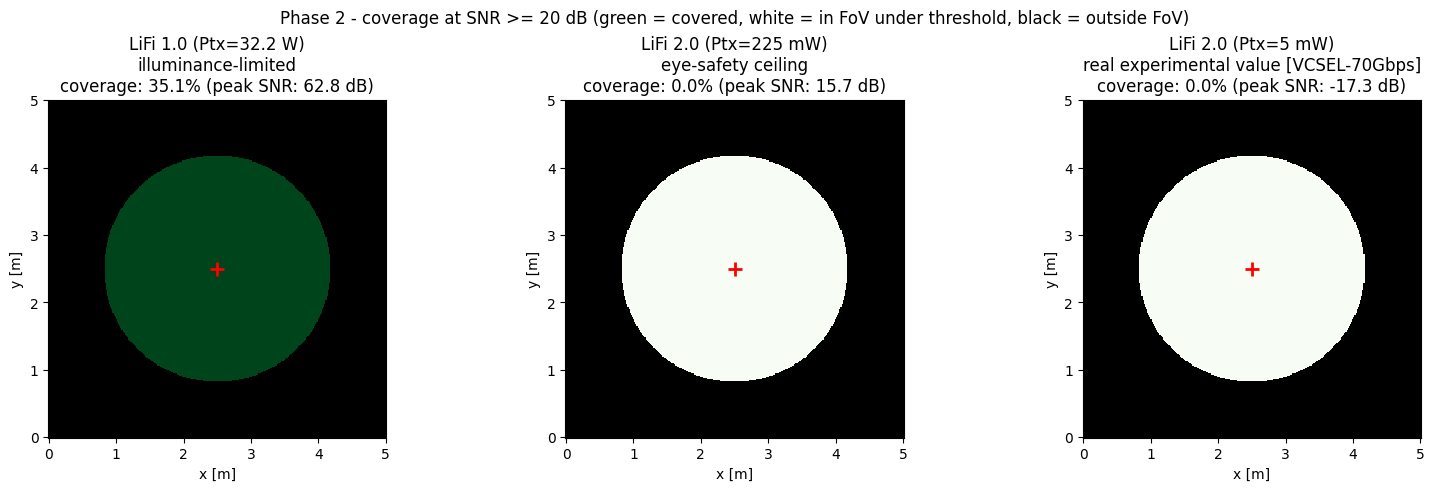

In [11]:
_, _, SNR_led_re, SNR_vcsel_eyesafe, _, R_vcsel_eyesafe = snr_rate(PTX_LED_REALISTIC, PTX_VCSEL_EYESAFE)
_, _, _, SNR_vcsel_exp, _, R_vcsel_exp = snr_rate(PTX_LED_REALISTIC, PTX_VCSEL_EXPERIMENTAL)

GAMMA_TH_DB = 20.0  # SNR threshold used to define "covered" [dB]
gamma_th = 10**(GAMMA_TH_DB / 10)
cov_led_re = SNR_led_re >= gamma_th # coverage map, LED at realistic power
cov_vcsel_eyesafe_map = SNR_vcsel_eyesafe >= gamma_th # coverage map, VCSEL at the eye-safety ceiling
cov_vcsel_exp_map = SNR_vcsel_exp >= gamma_th  # coverage map, VCSEL at the experimental power

cov_cmap = plt.cm.Greens.copy()
cov_cmap.set_bad("black")
# unified receiver: the same FoV mask (in_fov, from Section 3.1) applies to both technologies

def cov_black_outside(cov, in_fov):
    return np.where(in_fov, cov.astype(float), np.nan)  

# peak SNR per scenario, so a 0%-coverage panel still shows how close (or far) it got from the threshold
peak_snr_led_dB = 10 * np.log10(np.nanmax(SNR_led_re))
peak_snr_eyesafe_dB = 10 * np.log10(np.nanmax(SNR_vcsel_eyesafe))
peak_snr_exp_dB = 10 * np.log10(np.nanmax(SNR_vcsel_exp))

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.8), constrained_layout=True)
panels = [
    (cov_black_outside(cov_led_re, in_fov), cov_led_re, peak_snr_led_dB,
     f"LiFi 1.0 (Ptx={PTX_LED_REALISTIC:.1f} W)\nilluminance-limited"),
    (cov_black_outside(cov_vcsel_eyesafe_map, in_fov), cov_vcsel_eyesafe_map, peak_snr_eyesafe_dB,
     f"LiFi 2.0 (Ptx={PTX_VCSEL_EYESAFE*1e3:.0f} mW)\neye-safety ceiling"),
    (cov_black_outside(cov_vcsel_exp_map, in_fov), cov_vcsel_exp_map, peak_snr_exp_dB,
     f"LiFi 2.0 (Ptx={PTX_VCSEL_EXPERIMENTAL*1e3:.0f} mW)\nreal experimental value [VCSEL-70Gbps]"),
]
for ax, (cov_disp, cov_bool, peak_snr_dB, title) in zip(axes, panels):
    ax.pcolormesh(X, Y, cov_disp, shading="auto", cmap=cov_cmap, vmin=0, vmax=1)
    ax.plot(*TX_POS[:2], "r+", markersize=10, mew=2)
    ax.set_title(f"{title}\ncoverage: {100*cov_bool.mean():.1f}% (peak SNR: {peak_snr_dB:.1f} dB)")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal")
fig.suptitle(f"Phase 2 - coverage at SNR >= {GAMMA_TH_DB:.0f} dB "
             "(green = covered, white = in FoV under threshold, black = outside FoV)")
plt.show()


Taking realistic power levels into account, the single LED covers just over a third of the room; that is essentially its **entire FoV disk**, so at this power the LED is FoV-limited rather than power-limited. The single VCSEL, in contrast, covers 0% at the 20 dB threshold with either power anchor: its peak SNR only reaches ~16 dB at the (optimistic) eye-safety ceiling and stays far below 0 dB at the experimental 5 mW operating power.

### 4.4 Summary table and energy efficiency

In [12]:
import pandas as pd

R_led_re = 0.5 * B1 * np.log2(1 + K_BOUND * SNR_led_re)  # rate map at realistic LED power (not kept by the cell above)

def ee_peak_avg(rate_map, Ptx):
    # (peak, avg) energy efficiency in bit/J, from a rate map [bit/s] and Ptx [W]
    peak = np.nanmax(rate_map) / Ptx
    avg = np.nanmean(np.nan_to_num(rate_map, nan=0.0)) / Ptx
    return peak, avg

rows = []
def add_row(name, Ptx, SNR_map, R_map, cov_frac):
    ee_peak, ee_avg = ee_peak_avg(R_map, Ptx)
    rows.append({
        "Scenario": name,
        "Ptx": f"{Ptx:.4g} W",
        "Peak SNR [dB]": round(10 * np.log10(np.nanmax(SNR_map)), 1),
        "Peak rate [Mbit/s]": round(np.nanmax(R_map) / 1e6, 1),
        f"Coverage@{GAMMA_TH_DB:.0f}dB [%]": round(100 * cov_frac, 1),
        "EE peak [Mbit/J]": round(ee_peak / 1e6, 2),
        "EE avg [Mbit/J]": round(ee_avg / 1e6, 4),
    })

add_row("LiFi 1.0 (Phase 1, norm. 1 W)",     PTX_NORM,               SNR_led1,          R_led1,          np.mean(SNR_led1 >= gamma_th))
add_row("LiFi 2.0 (Phase 1, norm. 1 W)",     PTX_NORM,               SNR_vcsel1,        R_vcsel1,        np.mean(SNR_vcsel1 >= gamma_th))
add_row("LiFi 1.0 (Phase 2, realistic)",     PTX_LED_REALISTIC,      SNR_led_re,        R_led_re,        cov_led_re.mean())
add_row("LiFi 2.0 (Phase 2, eye-safety)",    PTX_VCSEL_EYESAFE,      SNR_vcsel_eyesafe, R_vcsel_eyesafe, cov_vcsel_eyesafe_map.mean())
add_row("LiFi 2.0 (Phase 2, experimental)",  PTX_VCSEL_EXPERIMENTAL, SNR_vcsel_exp,     R_vcsel_exp,     cov_vcsel_exp_map.mean())

summary_df = pd.DataFrame(rows)
summary_df

,Scenario,Ptx,Peak SNR [dB],Peak rate [Mbit/s],Coverage@20dB [%],EE peak [Mbit/J],EE avg [Mbit/J]
0,"LiFi 1.0 (Phase 1, norm. 1 W)",1 W,32.6,96.3,35.1,96.30,28.8573
1,"LiFi 2.0 (Phase 1, norm. 1 W)",1 W,28.7,8320.2,11.0,8320.20,1582.4449
2,"LiFi 1.0 (Phase 2, realistic)",32.15 W,62.8,196.4,35.1,6.11,1.9912
3,"LiFi 2.0 (Phase 2, eye-safety)",0.2249 W,15.7,4097.4,0.0,18217.66,2066.3906
4,"LiFi 2.0 (Phase 2, experimental)",0.005 W,-17.3,11.4,0.0,2289.24,126.0324


### 4.5 Spectral consideration - wavelength-dependent responsivity

Everywhere above both technologies use the same fixed responsivity $\rho = 1$ A/W, which is what isolates the channel and power effects. In reality the photodiode responsivity depends on the wavelength,

$$\rho(\lambda) = \eta\,\frac{q\,\lambda}{h\,c},$$

and for a silicon photodiode it grows with $\lambda$ up to the ~1100 nm cut-off. LiFi 1.0 emits across the visible band, while LiFi 2.0 emits in the near-IR (~950 nm), so at the same received optical power the VCSEL produces more photocurrent — the near-IR link benefits from the receiver's higher responsivity.

This is a receiver property, so it does not change any Phase 1/2 conclusion, but since $\text{SNR}\propto(\rho P_r)^2$ it does shift the SNR. I keep $\rho = 1$ as the baseline and only quantify the effect here with representative datasheet values.

In [13]:
Q_E = 1.602e-19    # electron charge [C]
H_PLANCK = 6.626e-34  # Planck constant [J*s]
C_LIGHT = 3e8      # speed of light [m/s]

def responsivity_ideal(lam_nm, eta=1.0):
    # ideal photodiode responsivity rho = eta*q*lambda/(h*c) [A/W]
    lam = lam_nm * 1e-9
    return eta * Q_E * lam / (H_PLANCK * C_LIGHT)

# representative silicon PIN photodiode values (datasheet-dependent)
RHO_LED = 0.4    # ~550 nm effective, visible band (LiFi 1.0) [A/W]
RHO_VCSEL = 0.6  # ~950 nm (LiFi 2.0) [A/W]

print(f"ideal rho (eta=1): @550nm = {responsivity_ideal(550):.2f} A/W, @950nm = {responsivity_ideal(950):.2f} A/W")
print(f"representative rho: LED (visible) = {RHO_LED} A/W, VCSEL (950 nm) = {RHO_VCSEL} A/W")

# effect on SNR: SNR ~ (rho*Pr)^2
d_snr_led_dB = 20 * np.log10(RHO_LED / RHO)
d_snr_vcsel_dB = 20 * np.log10(RHO_VCSEL / RHO)
print(f"\nSNR shift vs the rho=1 baseline: LED {d_snr_led_dB:+.1f} dB, VCSEL {d_snr_vcsel_dB:+.1f} dB")
print(f"Net relative shift in favour of the VCSEL: {d_snr_vcsel_dB - d_snr_led_dB:+.1f} dB")

# recompute Phase 2 coverage with the wavelength-dependent responsivities (same [RIS-VLC] eq. (12) SNR)
SNR_led_rho = (RHO_LED * PTX_LED_REALISTIC * H_led)**2 / (N0 * B1)
SNR_vcsel_rho = (RHO_VCSEL * PTX_VCSEL_EYESAFE * H_vcsel)**2 / (N0 * B2)
print(f"\nPhase 2 coverage @ {GAMMA_TH_DB:.0f} dB with wavelength-dependent rho:")
print(f"  LiFi 1.0 (rho={RHO_LED}):   {100*np.mean(SNR_led_rho >= gamma_th):.1f}%  (was {100*cov_led_re.mean():.1f}% at rho=1)")
print(f"  LiFi 2.0 (rho={RHO_VCSEL}): {100*np.mean(SNR_vcsel_rho >= gamma_th):.1f}%  (was {100*cov_vcsel_eyesafe_map.mean():.1f}% at rho=1)")
print("\n-> the +3.5 dB relative gain for the VCSEL doesn't flip the picture: a single VCSEL is still power-limited.")


ideal rho (eta=1): @550nm = 0.44 A/W, @950nm = 0.77 A/W
representative rho: LED (visible) = 0.4 A/W, VCSEL (950 nm) = 0.6 A/W

SNR shift vs the rho=1 baseline: LED -8.0 dB, VCSEL -4.4 dB
Net relative shift in favour of the VCSEL: +3.5 dB

Phase 2 coverage @ 20 dB with wavelength-dependent rho:
  LiFi 1.0 (rho=0.4):   35.1%  (was 35.1% at rho=1)
  LiFi 2.0 (rho=0.6): 0.0%  (was 0.0% at rho=1)

-> the +3.5 dB relative gain for the VCSEL doesn't flip the picture: a single VCSEL is still power-limited.


---

## 5. Interpretation

In Phase 1, since both transmitters used the same power and the same receiver, the channel models could be compared directly: the VCSEL concentrates a higher channel gain near the beam axis and converts its 2 GHz bandwidth into a much higher peak rate, while the LED spreads its power almost uniformly and gives better coverage across the shared FoV disk.

Once we consider realistic powers, everything comes down to how much optical power each transmitter is actually allowed to emit. An LED can put out the watts needed for room illumination without any issue; a single VCSEL is stuck in the milliwatt range because of eye-safety limits.

### 5.1 From a single VCSEL to an array

A single VCSEL does not provide sufficient room-scale coverage under realistic operating conditions. This naturally raises the question of whether that limitation can be overcome not by pushing more power out of one emitter, but by combining several low-power VCSELs instead, which is the direction `[VCSEL-Precoding]`'s array architecture actually takes.


### 5.2 Scaling analysis: equivalent optical power from multiple VCSELs

Here we keep the same Tx position, the same room, and the same receiver and SNR threshold as in Phase 2, and bundle $N$ VCSELs together at that single point, adding up their optical power directly (VCSELs from different emitters aren't mutually coherent, so intensities add rather than fields).

This is not yet a simulation of a real VCSEL array because
- it only estimates how the available optical power scales when several VCSELs are considered
- is meant as an order-of-magnitude study, not a precise prediction
- does not model beam overlap, emitter spacing, array geometry or signal processing

Those aspects should be addressed in the multi-cell analysis. 

The question here is just: if we had $N$ eye-safe VCSELs and stacked them all at the same point, how far would that get us?

I sweep $N$ over powers of two, from 1 up to 64, for both VCSEL power anchors used in Phase 2.


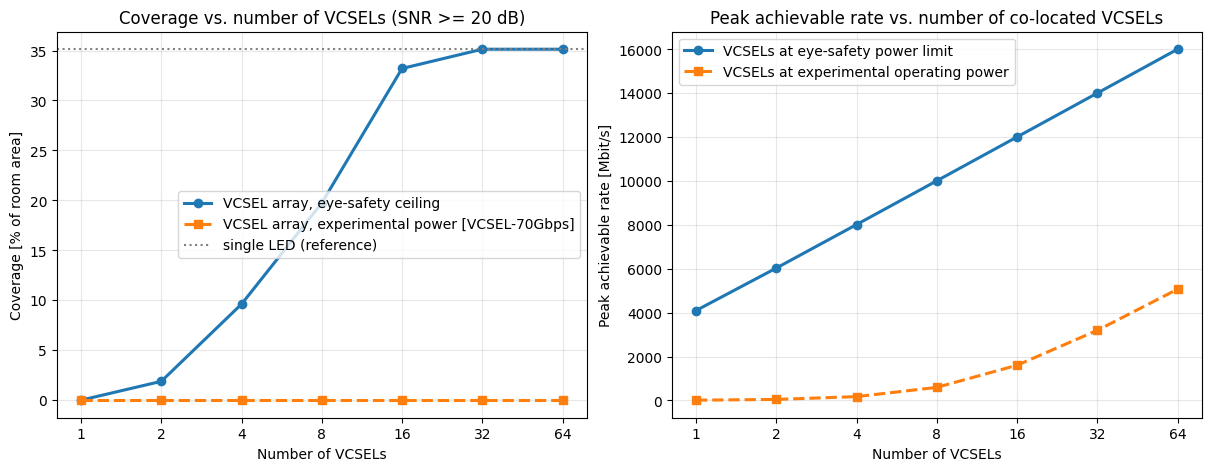

In [14]:
N_VCSEL_LIST = [1, 2, 4, 8, 16, 32, 64]  # how many VCSELs are bundled at the same tx point

cov_vs_N_eyesafe, cov_vs_N_exp = [], []  # coverage [%] for each N, one list per power anchor
peak_rate_vs_N_eyesafe, peak_rate_vs_N_exp = [], [] # peak achievable rate [Mbit/s] for each N

for n in N_VCSEL_LIST:
    Ptx_eyesafe_total = n * PTX_VCSEL_EYESAFE  # total optical power of the n-VCSEL bundle, eye-safety anchor
    Ptx_exp_total = n * PTX_VCSEL_EXPERIMENTAL # total optical power of the n-VCSEL bundle, experimental anchor
    _, _, _, SNR_n_eyesafe, _, R_n_eyesafe = snr_rate(PTX_LED_REALISTIC, Ptx_eyesafe_total)
    _, _, _, SNR_n_exp, _, R_n_exp = snr_rate(PTX_LED_REALISTIC, Ptx_exp_total)
    cov_vs_N_eyesafe.append(100 * np.mean(SNR_n_eyesafe >= gamma_th))
    cov_vs_N_exp.append(100 * np.mean(SNR_n_exp >= gamma_th))
    peak_rate_vs_N_eyesafe.append(np.nanmax(R_n_eyesafe) / 1e6)
    peak_rate_vs_N_exp.append(np.nanmax(R_n_exp) / 1e6)

cov_led_value = 100 * cov_led_re.mean()  # single-LED coverage from Phase 2, as a reference line

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)

ax = axes[0]
ax.plot(N_VCSEL_LIST, cov_vs_N_eyesafe, "o-", lw=2.2, label="VCSEL array, eye-safety ceiling")
ax.plot(N_VCSEL_LIST, cov_vs_N_exp, "s--", lw=2.2, label="VCSEL array, experimental power [VCSEL-70Gbps]")
ax.axhline(cov_led_value, color="gray", ls=":", lw=1.5, label="single LED (reference)")
ax.set_xscale("log", base=2)
ax.set_xticks(N_VCSEL_LIST)
ax.set_xticklabels(N_VCSEL_LIST)
ax.set_xlabel("Number of VCSELs")
ax.set_ylabel("Coverage [% of room area]")
ax.set_title(f"Coverage vs. number of VCSELs (SNR >= {GAMMA_TH_DB:.0f} dB)")
ax.legend()
ax.grid(alpha=.3)

ax = axes[1]
ax.plot(N_VCSEL_LIST, peak_rate_vs_N_eyesafe, "o-", lw=2.2, label="VCSELs at eye-safety power limit")
ax.plot(N_VCSEL_LIST, peak_rate_vs_N_exp, "s--", lw=2.2, label="VCSELs at experimental operating power")
ax.set_xscale("log", base=2)
ax.set_xticks(N_VCSEL_LIST)
ax.set_xticklabels(N_VCSEL_LIST)
ax.set_xlabel("Number of VCSELs")
ax.set_ylabel("Peak achievable rate [Mbit/s]")
ax.set_title("Peak achievable rate vs. number of co-located VCSELs")
ax.legend()
ax.grid(alpha=.3)

plt.show()


In [15]:
scaling_df = pd.DataFrame({
    "N": N_VCSEL_LIST,
    "Ptx_total eye-safety [W]": [round(n * PTX_VCSEL_EYESAFE, 3) for n in N_VCSEL_LIST],
    "Coverage eye-safety [%]": [round(c, 1) for c in cov_vs_N_eyesafe],
    "Ptx_total experimental [W]": [round(n * PTX_VCSEL_EXPERIMENTAL, 4) for n in N_VCSEL_LIST],
    "Coverage experimental [%]": [round(c, 1) for c in cov_vs_N_exp],
})
print(f"Reference: single LED coverage @ {GAMMA_TH_DB:.0f} dB = {cov_led_value:.1f}%")
print("chosen as a representative mid-range value; Phase 1 already showed the full sweep")
scaling_df

Reference: single LED coverage @ 20 dB = 35.1%
chosen as a representative mid-range value; Phase 1 already showed the full sweep


,N,Ptx_total eye-safety [W],Coverage eye-safety [%],Ptx_total experimental [W],Coverage experimental [%]
0,1,0.225,0.0,0.005,0.0
1,2,0.450,1.9,0.010,0.0
2,4,0.900,9.6,0.020,0.0
3,8,1.799,19.7,0.040,0.0
4,16,3.599,33.2,0.080,0.0
5,32,7.197,35.1,0.160,0.0
6,64,14.395,35.1,0.320,0.0


## 6. Transition to the multi-cell analysis

Bundling every VCSEL at the same point isn't a realistic array though. It only produces a single bright spot instead of uniform coverage, it can't serve more than one user at a time since every element points at the same place, and packing that many lasers together may no longer be eye-safe as a bundle.

This is exactly the gap from `[VCSEL-Precoding]`: an array distributed over the ceiling, precoded so that different (possibly overlapping) subsets of elements serve different users at once, instead of every element aiming at the same spot.

The next stage moves from this single-transmitter analysis to a multi-cell one, to see what a spatially distributed, precoded array actually achieves for coverage uniformity and multi-user capacity, not just for raw single-point power.
